## Feature Engineering

#### Load Cleaned Dataset

In [53]:
# import library
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
## Load dataset into a dataframe
df = pd.read_csv("../data/processed/cleaned_flipcart_laptop_data.csv")

## Top five observations
df.head()

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7 Ratings,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,NIL,NIL,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,"1,805 Ratings",143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...
3,Acer One (2024) Intel Core i3 11th Gen 1115G4 ...,COMGPF5CQ7VDWDT4,43999.0,26990.0,4.2,"6,977 Ratings",596 Reviews,Intel Core i3 Processor (11th Gen)8 GB DDR4 RA...,https://www.flipkart.com/acer-one-2024-intel-c...
4,Lenovo V15 AMD Ryzen 3 Quad Core 7320U - (8 GB...,COMGPYKZAWY8UX6C,59400.0,27989.0,4.2,"1,263 Ratings",113 Reviews,AMD Ryzen 3 Quad Core Processor8 GB LPDDR5 RAM...,https://www.flipkart.com/lenovo-v15-amd-ryzen-...


In [55]:
## Create "discount_pct(%)" column
df["discount_pct(%)"] = round(((df["Actual price"] - df["Discount price"]) / df["Actual price"]) * 100, 2)

# Display five observations of discount_pct(%) column
df["discount_pct(%)"].head()

0    38.89
1    19.05
2    27.58
3    38.66
4    52.88
Name: discount_pct(%), dtype: float64

In [56]:
df['Product Name'].sample(5)

766    ASUS Vivobook 16 Intel Core i5 12th Gen 12500H...
645    HP Spectre x360 Intel Core Ultra 7 155H - (32 ...
264    ASUS Vivobook Go 15 OLED (2023) AMD Ryzen 5 Qu...
818    MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...
660    Lenovo IdeaPad 3 Intel Core i3 12th Gen 1215U ...
Name: Product Name, dtype: str

We know that it contains all information about laptop.

Now we will extract information from it and create some other columns "processor", "ram_gb", "storage_gb", "storage_type".

In [57]:
## Import re module
import re

def extract_specs(name):
    specs = {}
    
    # Brand: first token
    specs['brand'] = name.split()[0]
    
    # CPU family: grab from Intel/AMD up to the next hyphen or opening parenthesis
    cpu_match = re.search(r'((?:Intel|AMD)[^-^(]+)', name, re.IGNORECASE)
    specs['processor'] = cpu_match.group(1).strip() if cpu_match else None
    
    # RAM size (first appearance of "NN GB" that is not storage)
    # We'll exclude matches immediately followed by SSD/HDD/EMMC
    ram_match = re.search(r'(\d+)\s*GB(?!\s*(?:SSD|HDD|EMMC))', name, re.IGNORECASE)
    specs['ram_gb'] = int(ram_match.group(1)) if ram_match else None
    
    # Storage: find all matches of capacity + unit + type
    stor_matches = re.findall(
        r'(\d+(?:\.\d+)?)\s*(GB|TB)\s*(SSD|HDD|EMMC)', 
        name, re.IGNORECASE
    )
    for size, unit, dtype in stor_matches:
        sz = float(size)
        if unit.upper() == 'TB':
            sz *= 1024
           
        specs['storage_gb'] = int(sz)
        specs['storage_type'] =  dtype.upper()

    return specs

# apply to DataFrame
extracted = df['Product Name'].apply(extract_specs).apply(pd.Series)

# Display first 5 observations of the extracted dataframe
extracted.head()

,brand,processor,ram_gb,storage_gb,storage_type
0,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD
1,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD
2,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD
3,Acer,Intel Core i3 11th Gen 1115G4,8.0,512.0,SSD
4,Lenovo,AMD Ryzen 3 Quad Core 7320U,8.0,512.0,SSD


In [58]:
## Basic information of **extracted** dataframe
extracted.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         953 non-null    str    
 1   processor     932 non-null    str    
 2   ram_gb        952 non-null    float64
 3   storage_gb    944 non-null    float64
 4   storage_type  944 non-null    str    
dtypes: float64(2), str(3)
memory usage: 37.4 KB


In [59]:
## Concatenate "df" and "extracted" dataframes
df = pd.concat([df, extracted], axis=1)

## Display first 5 observations
df.head()

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link,discount_pct(%),brand,processor,ram_gb,storage_gb,storage_type
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7 Ratings,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...,38.89,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,NIL,NIL,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...,19.05,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,"1,805 Ratings",143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...,27.58,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD
3,Acer One (2024) Intel Core i3 11th Gen 1115G4 ...,COMGPF5CQ7VDWDT4,43999.0,26990.0,4.2,"6,977 Ratings",596 Reviews,Intel Core i3 Processor (11th Gen)8 GB DDR4 RA...,https://www.flipkart.com/acer-one-2024-intel-c...,38.66,Acer,Intel Core i3 11th Gen 1115G4,8.0,512.0,SSD
4,Lenovo V15 AMD Ryzen 3 Quad Core 7320U - (8 GB...,COMGPYKZAWY8UX6C,59400.0,27989.0,4.2,"1,263 Ratings",113 Reviews,AMD Ryzen 3 Quad Core Processor8 GB LPDDR5 RAM...,https://www.flipkart.com/lenovo-v15-amd-ryzen-...,52.88,Lenovo,AMD Ryzen 3 Quad Core 7320U,8.0,512.0,SSD


In [60]:
# Check the information about the data frame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     953 non-null    str    
 1   ProductID        953 non-null    str    
 2   Actual price     953 non-null    float64
 3   Discount price   953 non-null    float64
 4   Stars            953 non-null    str    
 5   Rating           953 non-null    str    
 6   Reviews          953 non-null    str    
 7   Description      953 non-null    str    
 8   Link             953 non-null    str    
 9   discount_pct(%)  953 non-null    float64
 10  brand            953 non-null    str    
 11  processor        932 non-null    str    
 12  ram_gb           952 non-null    float64
 13  storage_gb       944 non-null    float64
 14  storage_type     944 non-null    str    
dtypes: float64(5), str(10)
memory usage: 111.8 KB


In [61]:
# Check how many null values contains each column of the dataframe df
df.isnull().sum()

Product Name        0
ProductID           0
Actual price        0
Discount price      0
Stars               0
Rating              0
Reviews             0
Description         0
Link                0
discount_pct(%)     0
brand               0
processor          21
ram_gb              1
storage_gb          9
storage_type        9
dtype: int64

In [62]:
# Check the % value 
((df["processor"].isnull().sum())/len(df))*100 + ((df["storage_gb"].isnull().sum())/len(df))*100 +((df["storage_type"].isnull().sum())/len(df))*100

np.float64(4.092339979013642)

In [63]:
# Drop null values
df.dropna(inplace=True)

# Check the information about the data frame
df.info()

<class 'pandas.DataFrame'>
Index: 923 entries, 0 to 952
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     923 non-null    str    
 1   ProductID        923 non-null    str    
 2   Actual price     923 non-null    float64
 3   Discount price   923 non-null    float64
 4   Stars            923 non-null    str    
 5   Rating           923 non-null    str    
 6   Reviews          923 non-null    str    
 7   Description      923 non-null    str    
 8   Link             923 non-null    str    
 9   discount_pct(%)  923 non-null    float64
 10  brand            923 non-null    str    
 11  processor        923 non-null    str    
 12  ram_gb           923 non-null    float64
 13  storage_gb       923 non-null    float64
 14  storage_type     923 non-null    str    
dtypes: float64(5), str(10)
memory usage: 115.4 KB


### Convert Data Type
#### Rating column

In [64]:
## Convert Ratings column object into float
df["Rating"] = df["Rating"].str.replace("Ratings", "", regex=True).str.replace(",", "").str.replace("NIL", "0").astype(float)

# Display Ratings column
df["Rating"] 

0         7.0
1         0.0
2      1805.0
3      6977.0
4      1263.0
        ...  
948     508.0
949     108.0
950    3897.0
951      53.0
952    5540.0
Name: Rating, Length: 923, dtype: float64

#### Stars column

In [65]:
## Convert Ratings column object into float
df["Stars"] = df['Stars'].str.replace("NIL", "0").astype(float)

# Display Ratings column
df["Stars"] 

0      3.9
1      0.0
2      4.2
3      4.2
4      4.2
      ... 
948    4.4
949    4.1
950    4.3
951    3.8
952    4.2
Name: Stars, Length: 923, dtype: float64

#### Review column

In [66]:
# Convert Ratings column object into float
df["Reviews"] = df["Reviews"].str.replace("Reviews", "", regex=True).str.replace(",", "").str.replace("NIL", "0").astype(float)
# Display Ratings column
df["Reviews"] 

0        1.0
1        0.0
2      143.0
3      596.0
4      113.0
       ...  
948     77.0
949     16.0
950    457.0
951      5.0
952    485.0
Name: Reviews, Length: 923, dtype: float64

In [67]:
df.info()

<class 'pandas.DataFrame'>
Index: 923 entries, 0 to 952
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     923 non-null    str    
 1   ProductID        923 non-null    str    
 2   Actual price     923 non-null    float64
 3   Discount price   923 non-null    float64
 4   Stars            923 non-null    float64
 5   Rating           923 non-null    float64
 6   Reviews          923 non-null    float64
 7   Description      923 non-null    str    
 8   Link             923 non-null    str    
 9   discount_pct(%)  923 non-null    float64
 10  brand            923 non-null    str    
 11  processor        923 non-null    str    
 12  ram_gb           923 non-null    float64
 13  storage_gb       923 non-null    float64
 14  storage_type     923 non-null    str    
dtypes: float64(8), str(7)
memory usage: 115.4 KB


In [68]:
df['Product Name'][10]

'ASUS TUF Gaming A15 (2024) AMD Ryzen 7 Octa Core 8845HS - (16 GB/512 GB SSD/Windows 11 Home/8 GB Graph...'

#### Create Processor_tier column

In [69]:
# Define a function
def assign_processor_tier(cpu):
    if pd.isna(cpu):
        return None
    cpu = cpu.lower()
    if 'core i3' in cpu or 'ryzen 3' in cpu or 'pentium' in cpu or 'celeron' in cpu:
        return 'Entry'
    elif 'core i5' in cpu or 'ryzen 5' in cpu:
        return 'Mid'
    elif 'core i7' in cpu or 'ryzen 7' in cpu:
        return 'High'
    elif 'core i9' in cpu or 'ryzen 9' in cpu or 'core ultra' in cpu:
        return 'Ultra'
    else:
        return 'Other'

# Apply to our DataFrame
df['processor_tier'] = df['processor'].apply(assign_processor_tier)

# Display first 5 observation
df.head(5)

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link,discount_pct(%),brand,processor,ram_gb,storage_gb,storage_type,processor_tier
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7.0,1.0,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...,38.89,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD,Mid
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,0.0,0.0,0.0,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...,19.05,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD,High
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,1805.0,143.0,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...,27.58,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD,Entry
3,Acer One (2024) Intel Core i3 11th Gen 1115G4 ...,COMGPF5CQ7VDWDT4,43999.0,26990.0,4.2,6977.0,596.0,Intel Core i3 Processor (11th Gen)8 GB DDR4 RA...,https://www.flipkart.com/acer-one-2024-intel-c...,38.66,Acer,Intel Core i3 11th Gen 1115G4,8.0,512.0,SSD,Entry
4,Lenovo V15 AMD Ryzen 3 Quad Core 7320U - (8 GB...,COMGPYKZAWY8UX6C,59400.0,27989.0,4.2,1263.0,113.0,AMD Ryzen 3 Quad Core Processor8 GB LPDDR5 RAM...,https://www.flipkart.com/lenovo-v15-amd-ryzen-...,52.88,Lenovo,AMD Ryzen 3 Quad Core 7320U,8.0,512.0,SSD,Entry


In [70]:
df.describe()

,Actual price,Discount price,Stars,Rating,Reviews,discount_pct(%),ram_gb,storage_gb
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,75354.066089,54495.817985,3.581040,997.331528,92.006501,28.845330,11.813651,553.152763
std,36051.320904,31239.227218,1.532652,1784.997022,164.005562,9.862427,5.011045,218.346988
min,21990.000000,13990.000000,0.000000,0.000000,0.000000,0.670000,4.000000,32.000000
25%,51967.000000,35990.000000,3.800000,3.000000,1.000000,21.715000,8.000000,512.000000
50%,69890.000000,47990.000000,4.200000,70.000000,8.000000,28.110000,8.000000,512.000000
75%,88990.000000,63990.000000,4.300000,997.000000,101.000000,36.165000,16.000000,512.000000
max,499990.000000,439990.000000,5.000000,12482.000000,1042.000000,60.020000,64.000000,2048.000000


In [71]:
low, mid = [55000, 80000]
print(low, mid)

55000 80000


In [72]:
# Define function
def budget_range(price):

    if (price <= low):
        return "budget"
    elif (price <= mid):
        return "mid range"
    else:
        return "premium"
    
# Create a new column
df["price_tier"] = df["Discount price"].apply(budget_range)

# Display the dataframe with 5 observations
df.head(3)

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link,discount_pct(%),brand,processor,ram_gb,storage_gb,storage_type,processor_tier,price_tier
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7.0,1.0,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...,38.89,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD,Mid,budget
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,0.0,0.0,0.0,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...,19.05,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD,High,mid range
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,1805.0,143.0,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...,27.58,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD,Entry,budget


In [73]:
df.info()

<class 'pandas.DataFrame'>
Index: 923 entries, 0 to 952
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     923 non-null    str    
 1   ProductID        923 non-null    str    
 2   Actual price     923 non-null    float64
 3   Discount price   923 non-null    float64
 4   Stars            923 non-null    float64
 5   Rating           923 non-null    float64
 6   Reviews          923 non-null    float64
 7   Description      923 non-null    str    
 8   Link             923 non-null    str    
 9   discount_pct(%)  923 non-null    float64
 10  brand            923 non-null    str    
 11  processor        923 non-null    str    
 12  ram_gb           923 non-null    float64
 13  storage_gb       923 non-null    float64
 14  storage_type     923 non-null    str    
 15  processor_tier   923 non-null    str    
 16  price_tier       923 non-null    str    
dtypes: float64(8), str(9)
memory usa

In [74]:
corr = df.select_dtypes(include=np.number).corr()
corr

,Actual price,Discount price,Stars,Rating,Reviews,discount_pct(%),ram_gb,storage_gb
Actual price,1.000000,0.960185,-0.388017,-0.312334,-0.312371,-0.247195,0.704528,0.581801
Discount price,0.960185,1.000000,-0.459860,-0.263672,-0.267718,-0.475563,0.687757,0.610633
Stars,-0.388017,-0.459860,1.000000,0.223466,0.222236,0.378932,-0.183256,-0.454921
Rating,-0.312334,-0.263672,0.223466,1.000000,0.979480,-0.061100,-0.177360,-0.133258
Reviews,-0.312371,-0.267718,0.222236,0.979480,1.000000,-0.039601,-0.191184,-0.130901
discount_pct(%),-0.247195,-0.475563,0.378932,-0.061100,-0.039601,1.000000,-0.245660,-0.357775
ram_gb,0.704528,0.687757,-0.183256,-0.177360,-0.191184,-0.245660,1.000000,0.362797
storage_gb,0.581801,0.610633,-0.454921,-0.133258,-0.130901,-0.357775,0.362797,1.000000


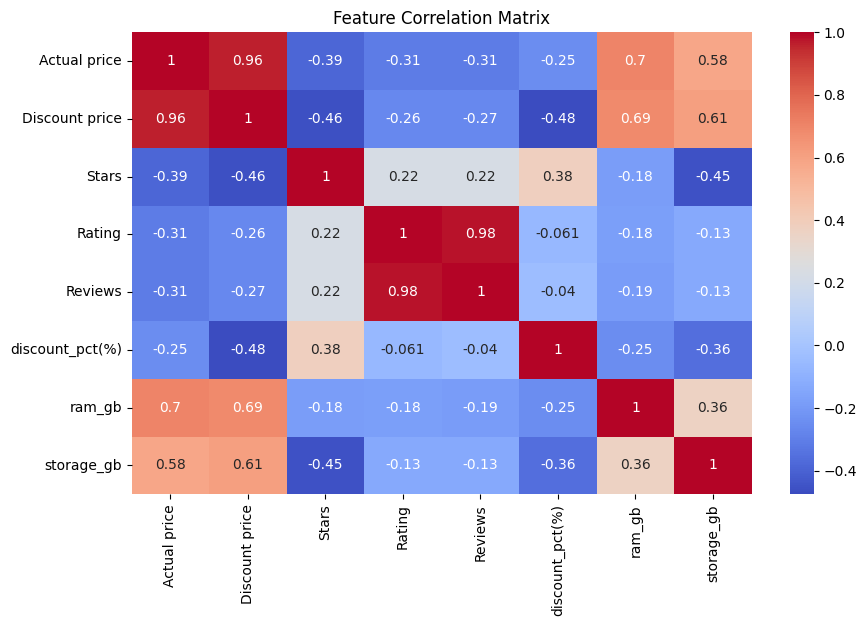

In [75]:
plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

##### **is_gaming** feature extraction

In [76]:
gaming_keywords = ["gaming", "rog", "tuf", "predator", "legion"]

pattern = "|".join(gaming_keywords)

df["is_gaming"] = (
    df["Product Name"].str.contains(pattern,case=False,na=False
    ).astype(int)
)

df["is_gaming"]

0      0
1      0
2      0
3      0
4      0
      ..
948    1
949    0
950    0
951    0
952    0
Name: is_gaming, Length: 923, dtype: int64

In [77]:
df["is_gaming"].value_counts()

is_gaming
0    879
1     44
Name: count, dtype: int64

##### **has_rtx** feature extraction

In [78]:
df["has_rtx"] = (
    df["Product Name"].str.contains("RTX",case=False,na=False
    ).astype(int)
)

df["has_rtx"]

0      0
1      0
2      0
3      0
4      0
      ..
948    0
949    0
950    0
951    0
952    0
Name: has_rtx, Length: 923, dtype: int64

In [79]:
df['has_rtx'].value_counts()

has_rtx
0    920
1      3
Name: count, dtype: int64

**Comments**:
From above analysis, we can see that
- only 3 rows contain RTX. So, feature is extremely imbalanced.
- The model cannot learn meaningful patterns from only 3 samples.
- Sparse features with extremely low representation were removed to avoid overfitting and improve model generalization.

##### **processor_brand** extraction

In [80]:
df["processor"]

0      Intel Core i5 12th Gen 12450H
1      Intel Core i7 12th Gen 12650H
2       Intel Core i3 12th Gen 1215U
3      Intel Core i3 11th Gen 1115G4
4        AMD Ryzen 3 Quad Core 7320U
                   ...              
948    Intel Core i7 11th Gen 11800H
949          Intel Core Ultra 5 125H
950    Intel Core i3 10th Gen 1005G1
951    Intel Core i5 12th Gen 12450H
952     Intel Core i3 12th Gen 1215U
Name: processor, Length: 923, dtype: str

In [81]:
def extract_processor_brand(text):

    text = str(text).lower()

    if "intel" in text:
        return "Intel"

    elif "amd" in text:
        return "AMD"

    elif "apple" in text:
        return "Apple"

    else:
        return "Other"
    

df["processor_brand"] = df["processor"].apply(extract_processor_brand)
df["processor_brand"]

0      Intel
1      Intel
2      Intel
3      Intel
4        AMD
       ...  
948    Intel
949    Intel
950    Intel
951    Intel
952    Intel
Name: processor_brand, Length: 923, dtype: str

In [82]:
df["processor_brand"].value_counts()

processor_brand
Intel    722
AMD      201
Name: count, dtype: int64

##### **processor_generation** extraction

In [83]:
df["processor_generation"] = (
    df["processor"].str.extract(r'(\d{1,2})(?:th)?\s*Gen')
)
df["processor_generation"]

0       12
1       12
2       12
3       11
4      NaN
      ... 
948     11
949    NaN
950     10
951     12
952     12
Name: processor_generation, Length: 923, dtype: str

In [84]:
df["processor_generation"].isna().sum()

np.int64(288)

- Handle Missing Values

##### **premium_brand** feature extraction

In [85]:
df["processor_generation"] = (
    df["processor_generation"].fillna(0).astype(int)
)
## Check total no. of nan values
df["processor_generation"].isna().sum()

np.int64(0)

In [86]:
premium_brands = ["Apple", "MSI", "Alienware"]

df["premium_brand"] = (
    df["brand"].isin(premium_brands).astype(int)
)

df["premium_brand"]

0      1
1      1
2      0
3      0
4      0
      ..
948    0
949    0
950    0
951    0
952    0
Name: premium_brand, Length: 923, dtype: int64

In [87]:
df["premium_brand"].value_counts()

premium_brand
0    751
1    172
Name: count, dtype: int64

In [88]:
def extract_gpu_type(text):

    text = str(text).lower()

    if "rtx" in text:
        return "RTX"

    elif "gtx" in text:
        return "GTX"

    elif "radeon" in text:
        return "Radeon"

    elif "intel iris" in text:
        return "Integrated"

    else:
        return "Other"
    

df["gpu_type"] = df["Description"].apply(extract_gpu_type)
df["gpu_type"]

0      Other
1      Other
2      Other
3      Other
4      Other
       ...  
948    Other
949    Other
950    Other
951    Other
952    Other
Name: gpu_type, Length: 923, dtype: str

In [89]:
df["gpu_type"].value_counts()

gpu_type
Other    923
Name: count, dtype: int64

### Drop unnecessary features

In [90]:
df.columns

Index(['Product Name', 'ProductID', 'Actual price', 'Discount price', 'Stars',
       'Rating', 'Reviews', 'Description', 'Link', 'discount_pct(%)', 'brand',
       'processor', 'ram_gb', 'storage_gb', 'storage_type', 'processor_tier',
       'price_tier', 'is_gaming', 'has_rtx', 'processor_brand',
       'processor_generation', 'premium_brand', 'gpu_type'],
      dtype='str')

In [91]:
df.drop(columns=['Product Name', 'ProductID', 'Actual price', 'Description', 'Link', 'processor', 'price_tier', 'has_rtx', 'gpu_type'], inplace=True)

df.head()

,Discount price,Stars,Rating,Reviews,discount_pct(%),brand,ram_gb,storage_gb,storage_type,processor_tier,is_gaming,processor_brand,processor_generation,premium_brand
0,54990.0,3.9,7.0,1.0,38.89,MSI,16.0,512.0,SSD,Mid,0,Intel,12,1
1,67990.0,0.0,0.0,0.0,19.05,MSI,8.0,1024.0,SSD,High,0,Intel,12,1
2,35660.0,4.2,1805.0,143.0,27.58,DELL,8.0,512.0,SSD,Entry,0,Intel,12,0
3,26990.0,4.2,6977.0,596.0,38.66,Acer,8.0,512.0,SSD,Entry,0,Intel,11,0
4,27989.0,4.2,1263.0,113.0,52.88,Lenovo,8.0,512.0,SSD,Entry,0,AMD,0,0


In [92]:
df.info()

<class 'pandas.DataFrame'>
Index: 923 entries, 0 to 952
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Discount price        923 non-null    float64
 1   Stars                 923 non-null    float64
 2   Rating                923 non-null    float64
 3   Reviews               923 non-null    float64
 4   discount_pct(%)       923 non-null    float64
 5   brand                 923 non-null    str    
 6   ram_gb                923 non-null    float64
 7   storage_gb            923 non-null    float64
 8   storage_type          923 non-null    str    
 9   processor_tier        923 non-null    str    
 10  is_gaming             923 non-null    int64  
 11  processor_brand       923 non-null    str    
 12  processor_generation  923 non-null    int64  
 13  premium_brand         923 non-null    int64  
dtypes: float64(7), int64(3), str(4)
memory usage: 140.5 KB


### Distribution of Numerical Columns

In [93]:
def plot_distribution(df, column):

    plt.figure(figsize=(14,5))
    # Histogram
    plt.subplot(1,2,1)

    sns.histplot(df[column], kde=True, bins=30)

    plt.title(f"Distribution of {column}")


    # Boxplot
    plt.subplot(1,2,2)

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

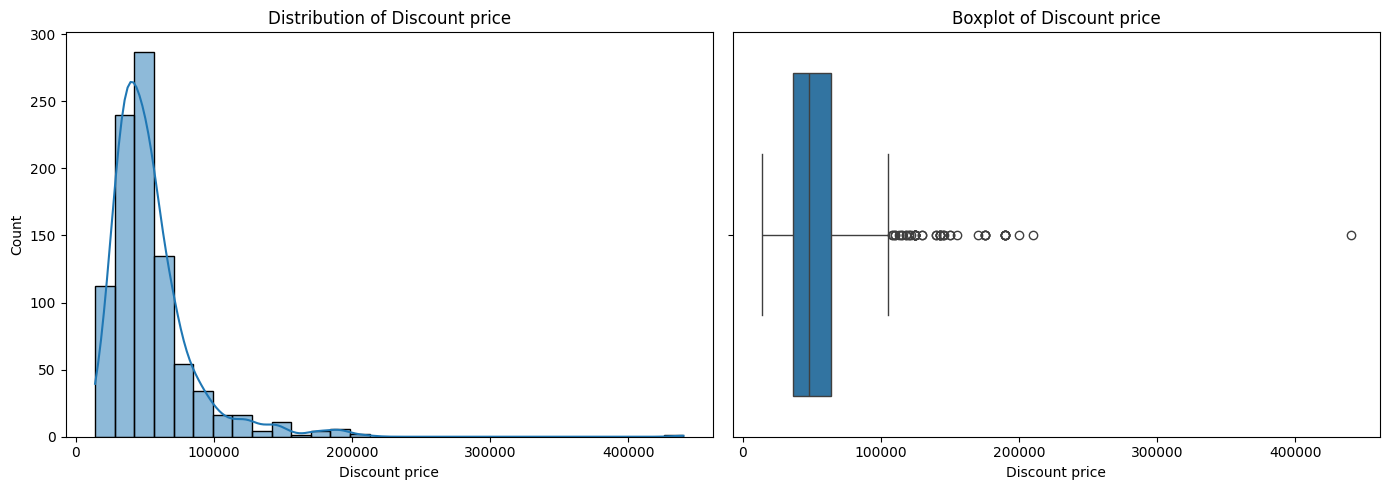

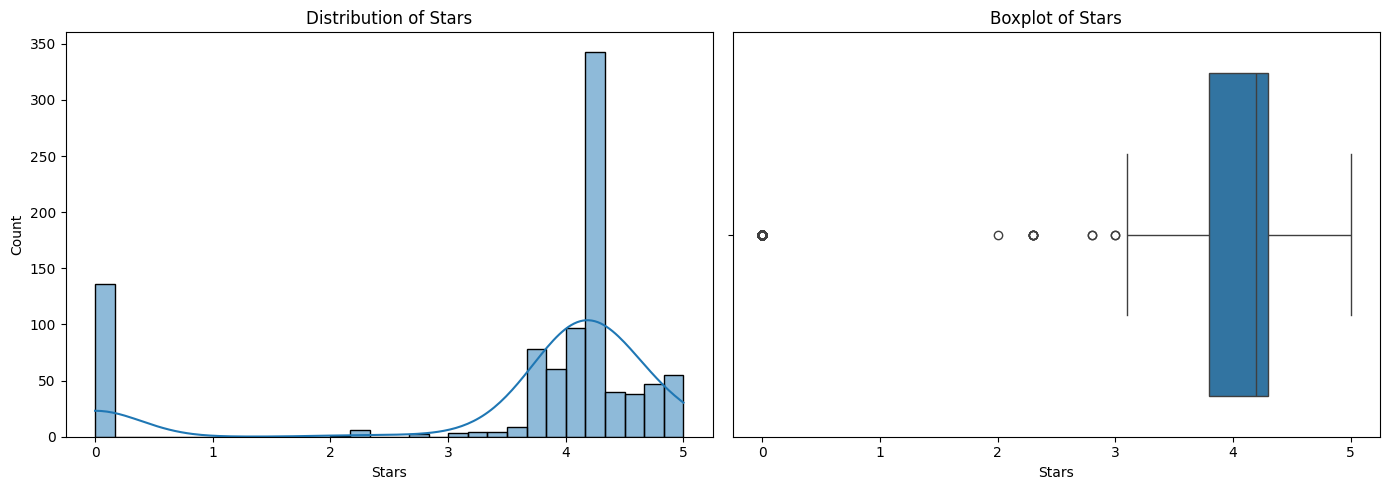

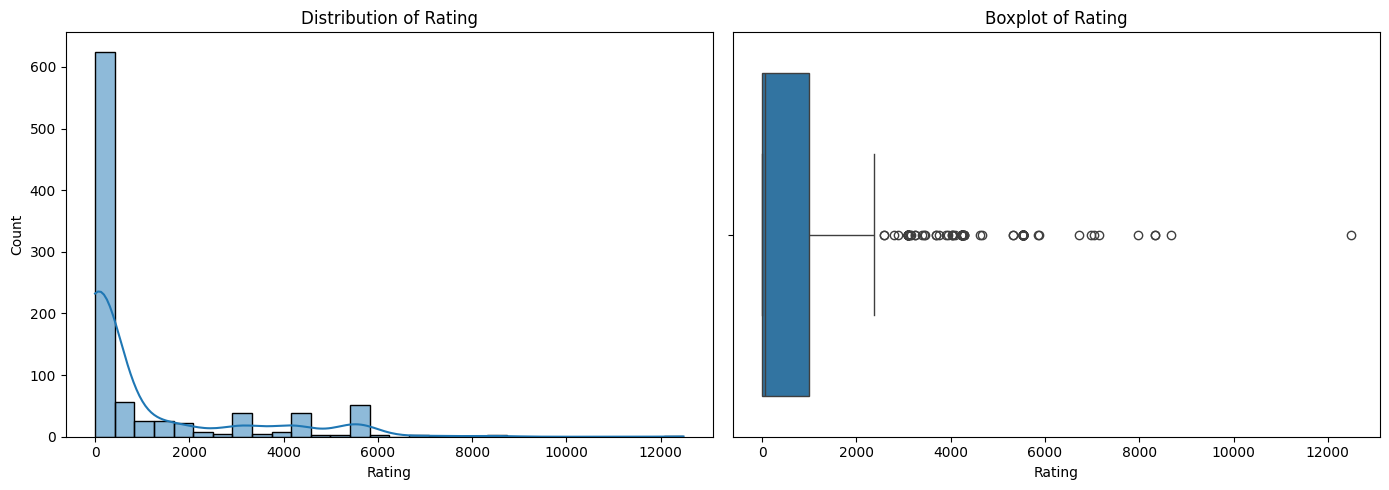

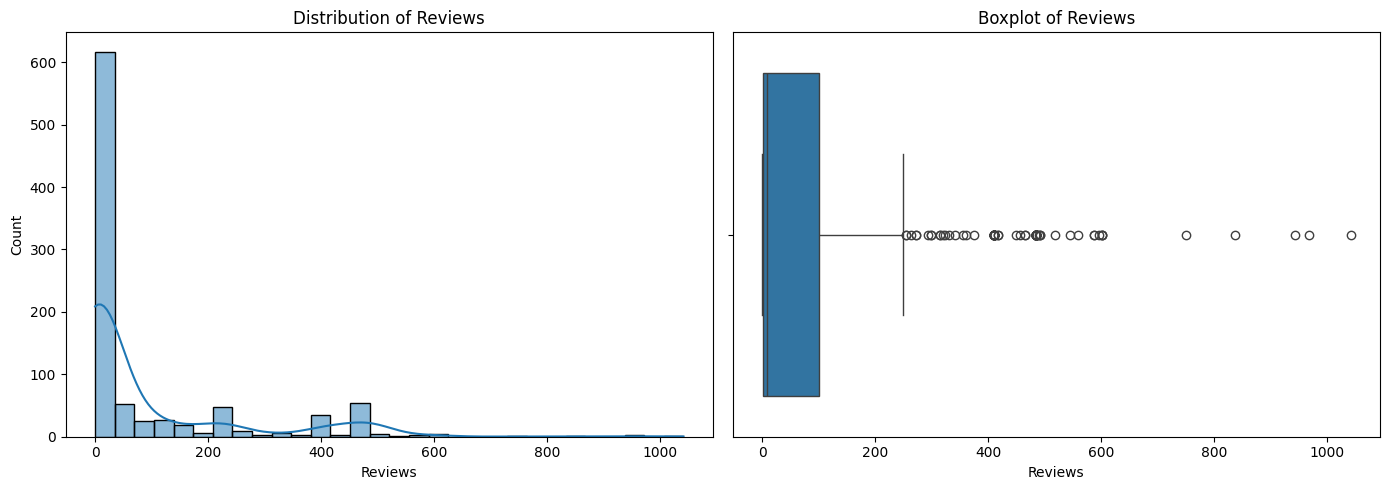

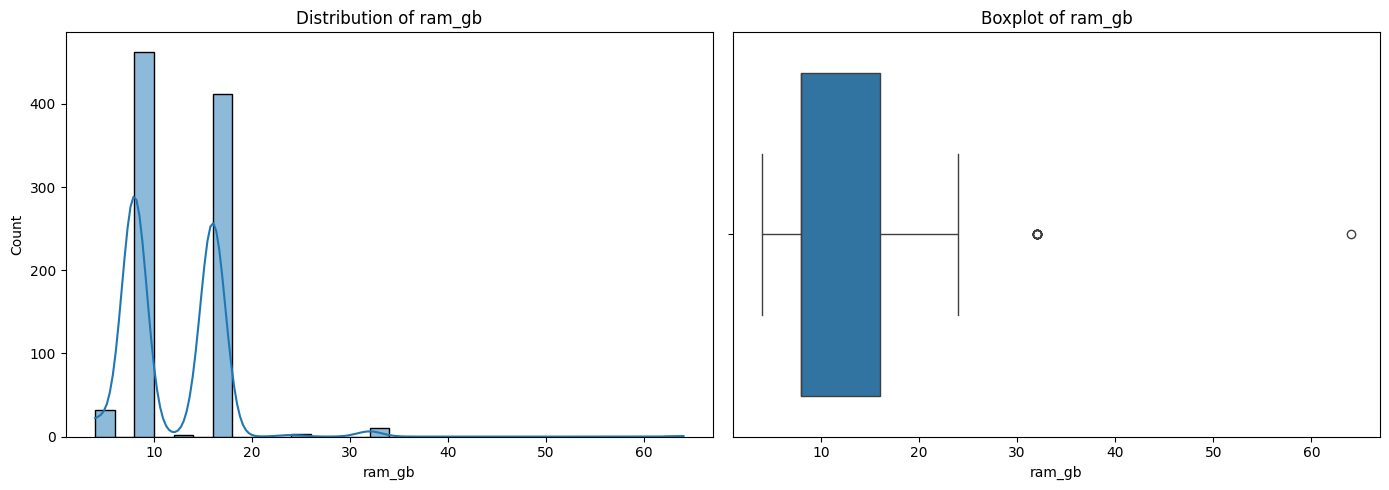

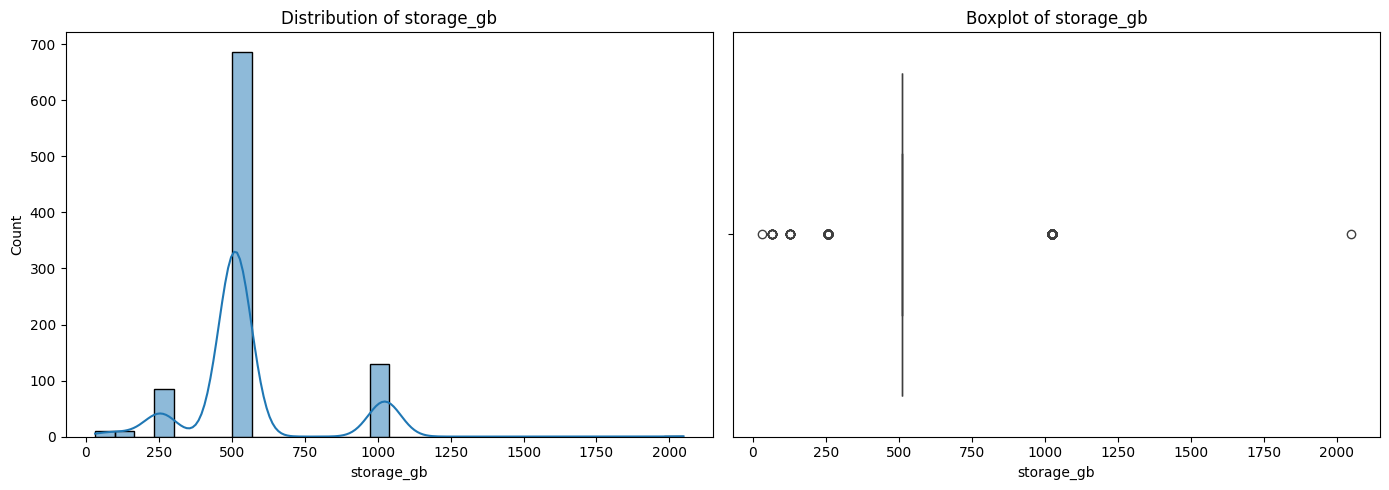

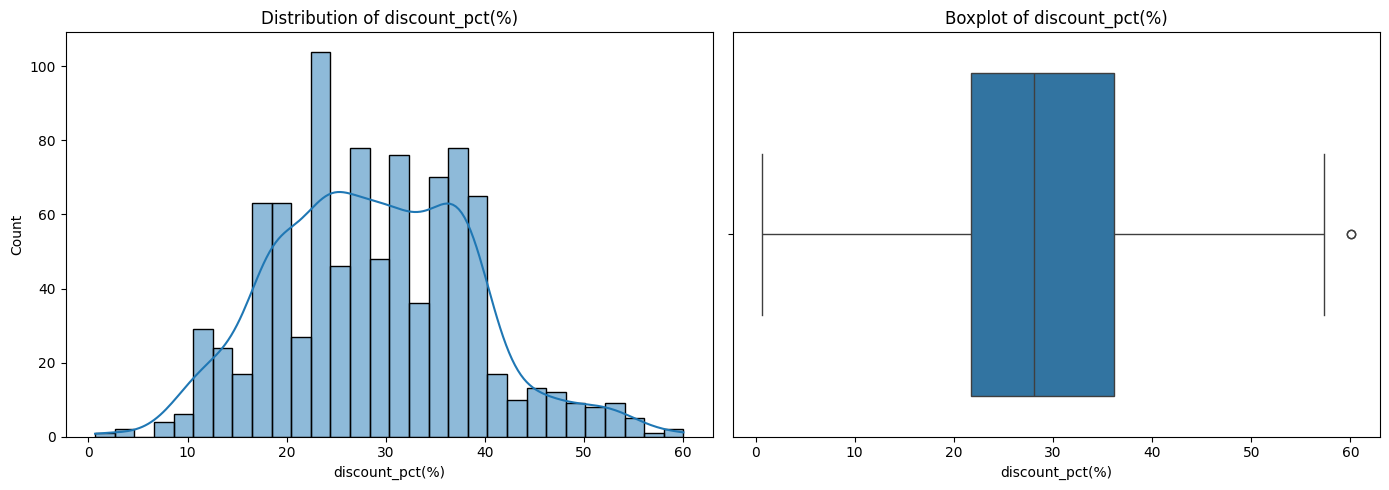

In [94]:
num_cols = ["Discount price", "Stars", "Rating", 'Reviews', 'ram_gb', 'storage_gb', 'discount_pct(%)']

for col in num_cols:
    plot_distribution(df, col)

In [95]:
df.to_csv("../data/processed/feature_engineered_flipcart_laptop_data.csv",index=False)